64.0


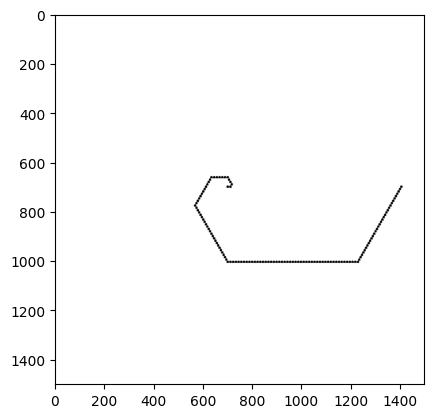

In [231]:
import numpy as np
import matplotlib.pyplot as plt

pads_x = (z:=np.expand_dims(np.arange(1001)-500, 0)) + (z.T / 2)
pads_y = np.column_stack([z[0]*(0.75 ** 0.5)]*1001)
pads_direct = np.mod(np.atan2(pads_x-pads_x[500,500], -(pads_y-pads_y[500,500])), 2*np.pi)
pads_direct[500,500] = 1.58
pads_dist = np.sqrt((pads_x-pads_x[500,500])**2 + (pads_y-pads_y[500,500])**2)
mv_options = np.array([[-1,0], [-1,1], [0,1], [1,0], [1,-1], [0,-1]])

img = np.zeros((1500,1500), dtype=int)

def update_img(y,x):
    cy,cx = y*11+700, x*11+700
    tly = np.floor(cy-6).astype(int)
    tlx = np.floor(cx-6).astype(int)
    img[tly:tly+11, tlx:tlx+11] = np.maximum(img[tly:tly+11, tlx:tlx+11],
                                             (np.round(np.sqrt(np.expand_dims(np.arange(11)+tly-cy, 1)**2 
                                                               + np.expand_dims(np.arange(11)+tlx-cx, 0)**2)) <= 5).astype(int))

frog_loc = np.array([500,500])
update_img(pads_y[*frog_loc],pads_x[*frog_loc])
while pads_y[*frog_loc] != 0 or pads_x[*frog_loc] <= 1:
    newloc_poss = frog_loc+mv_options
    direct_change = np.round(np.mod(pads_direct[*frog_loc] - pads_direct[newloc_poss[:, 0], newloc_poss[:, 1]], 2*np.pi), 10)
    dist_change = np.round(pads_dist[newloc_poss[:, 0], newloc_poss[:, 1]] - pads_dist[*frog_loc], 10)
    filt = (direct_change > 0) & (direct_change < np.pi) & (dist_change > 0)
    frog_loc = newloc_poss[filt][np.lexsort((direct_change[filt], np.round(dist_change[filt], 10)))][0]
    update_img(pads_y[*frog_loc],pads_x[*frog_loc])

print(pads_x[*frog_loc].item())

plt.imshow(img, cmap='gray_r')